In [1]:

# ── Colab setup ──────────────────────────────────────────────────────────────
# When running locally this cell does nothing.
# When running in Google Colab, clones the repo and fetches international data.
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists('raw_matches.csv'):
    REPO_URL = 'https://github.com/emaforlin/world_cup_learning_modernized.git'
    !git clone {REPO_URL} /content/wcl
    os.chdir('/content/wcl')
    sys.path.insert(0, '/content/wcl')

if not os.path.exists('raw_international.csv'):
    import subprocess
    subprocess.run([sys.executable, 'fetch_international.py'], check=True)


In [2]:
import utils

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Normalization
from tensorflow.keras.callbacks import EarlyStopping

2026-06-07 19:40:45.699456: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-07 19:40:45.702079: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-07 19:40:45.734740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-07 19:40:45.749919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-07 19:40:45.775656: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [3]:
input_cols = [
    'matches_won_percent',
    'podium_score_yearly',
    'recent_form',
    'recent_avg_goal_diff',
    'elo_rating',
    'is_host',
    'matches_won_percent_2',
    'podium_score_yearly_2',
    'recent_form_2',
    'recent_avg_goal_diff_2',
    'elo_rating_2',
    'is_host_2',
]
output_col = 'winner'

In [4]:
matches = utils.get_matches(with_team_stats=True, duplicate_with_reversed=True)
matches

,id,year,team1,score1,score2,team2,winner,is_host,is_host_2,matches_played,...,matches_won_2,years_played_2,podium_score_2,cups_won_2,recent_form_2,recent_avg_goal_diff_2,elo_rating_2,matches_won_percent_2,podium_score_yearly_2,cups_won_yearly_2
0,0,1950,Brazil,4,0,Mexico,True,1.0,0.0,20.836787,...,6.476608,16.0,0.000000,0.0,0.5,1.714286,1363.596378,0.526479,0.000000,0.000000
1,1,1950,Yugoslavia,3,0,Switzerland,True,0.0,0.0,2.313627,...,5.683966,10.0,0.000000,0.0,0.2,0.714286,1317.074972,0.548860,0.000000,0.000000
3,3,1950,Yugoslavia,4,1,Mexico,True,0.0,0.0,2.313627,...,6.476608,16.0,0.000000,0.0,0.5,1.714286,1363.596378,0.526479,0.000000,0.000000
4,4,1950,Brazil,2,0,Yugoslavia,True,1.0,0.0,20.836787,...,1.395946,8.0,0.070369,0.0,0.4,0.800000,1278.937434,0.603358,0.008796,0.000000
5,5,1950,Switzerland,2,1,Mexico,True,0.0,0.0,10.355941,...,6.476608,16.0,0.000000,0.0,0.5,1.714286,1363.596378,0.526479,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784,889,2022,Portugal,0,1,Morocco,False,0.0,0.0,13.011176,...,3.396362,6.0,2.000000,0.0,0.5,2.142857,1401.983021,0.417663,0.333333,0.000000
1785,890,2022,France,2,1,England,True,0.0,0.0,18.738164,...,9.819893,16.0,2.639232,1.0,0.5,1.714286,1424.983057,0.602265,0.164952,0.062500
1786,891,2022,Croatia,0,3,Argentina,False,0.0,0.0,12.147648,...,13.535450,16.0,20.864050,3.0,0.6,2.285714,1495.842185,0.722203,1.304003,0.187500
1787,892,2022,Morocco,0,2,France,False,0.0,0.0,8.131820,...,15.371265,13.0,29.135313,2.0,0.5,1.571429,1466.632545,0.820319,2.241178,0.153846


In [5]:
train, test = train_test_split(matches, test_size=0.2)

In [6]:
network = Sequential([
    Input((len(input_cols),)),
    Normalization(),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid'),
])

network.layers[0].adapt(train[input_cols].values)

network.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 12)             │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 251 (1004.00 B)

 Non-trainable params: 25 (104.00 B)

In [7]:
history = network.fit(
    train[input_cols], train[output_col],
    epochs=500,
    batch_size=128,
    validation_data=(test[input_cols], test[output_col]),
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
        )
    ],
)

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4982 - loss: 0.7268 - val_accuracy: 0.5507 - val_loss: 0.6974
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5417 - loss: 0.6984 - val_accuracy: 0.5833 - val_loss: 0.6786
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5971 - loss: 0.6753 - val_accuracy: 0.6123 - val_loss: 0.6648
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6361 - loss: 0.6568 - val_accuracy: 0.6159 - val_loss: 0.6536
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6633 - loss: 0.6413 - val_accuracy: 0.6413 - val_loss: 0.6444
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6815 - loss: 0.6275 - val_accuracy: 0.6486 - val_loss: 0.6352
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6969 - loss: 0.6154 - val_accuracy: 0.6413 - val_loss: 0.6259
Epoch 8/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7105 - loss: 0.6031 - val_accuracy: 0.6522 - val_loss: 0.6180

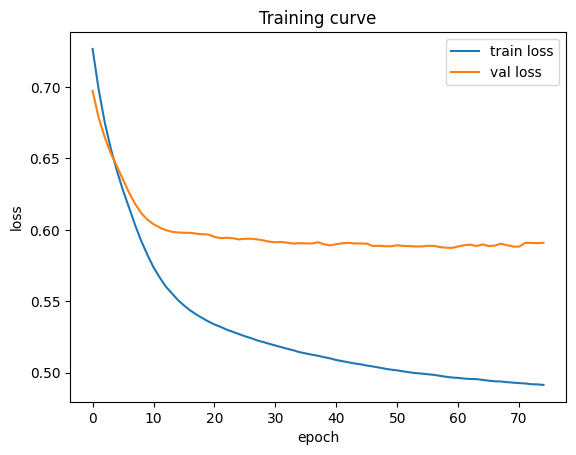

In [8]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training curve')
plt.legend()
plt.show()

In [9]:
train_predictions = network.predict(train[input_cols])

accuracy_score(train[output_col], train_predictions.round())

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


0.7577132486388385

In [10]:
test_predictions = network.predict(test[input_cols])

accuracy_score(test[output_col], test_predictions.round())

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.7028985507246377

In [11]:
# ── Goals regression model ────────────────────────────────────────────────────
goals_network = Sequential([
    Input((len(input_cols),)),
    Normalization(),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='relu'),  # [score1, score2] — relu keeps outputs non-negative
])

goals_network.layers[0].adapt(train[input_cols].values)

goals_network.compile(optimizer='adam', loss='mse')

goals_network.fit(
    train[input_cols],
    train[['score1', 'score2']],
    epochs=100,
    batch_size=128,
    verbose=0,
)

import numpy as np
goals_pred = goals_network.predict(test[input_cols], verbose=0)
mae = np.mean(np.abs(goals_pred - test[['score1', 'score2']].values))
print(f"Goals model — mean absolute error per score: {mae:.2f} goals")


Goals model — mean absolute error per score: 1.06 goals


In [12]:
def predict(year, team1, team2):
    case_inputs = utils.build_inputs_for_match(year, team1, team2, input_cols)
    result = network.predict(case_inputs)

    if result > 0.5:
        winner = team1
    else:
        winner = team2

    print(result[0][0], '→', winner)

In [13]:
def predict_score(year, team1, team2):
    """
    Predict the exact score of a match.
    A draw is a valid prediction — if the competition result is also a draw,
    the model earns 2 points.
    """
    case_inputs = utils.build_inputs_for_match(year, team1, team2, input_cols)

    raw = goals_network.predict(case_inputs, verbose=0)[0]
    s1, s2 = round(float(raw[0])), round(float(raw[1]))

    if s1 > s2:
        result = f"{team1} wins"
    elif s2 > s1:
        result = f"{team2} wins"
    else:
        result = "Draw"

    print(f"{team1} {s1} - {s2} {team2}   →   {result}")


In [14]:
predict(2026, 'Mexico', 'South Africa')  # real result: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0.8678907 → Mexico


In [ ]:
predict_score(2026, 'Mexico', 'South Africa')  # real result: 

In [15]:
predict(2026, 'South Korea', 'Czech Republic')  # real result:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0.5077802 → South Korea


In [ ]:
predict_score(2026, 'South Korea', 'Czech Republic')  # real result:

In [16]:
predict(2026, 'Canada', 'Bosnia Herzegovina')  # real result:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0.5058235 → Canada


In [ ]:
predict_score(2026, 'Canada', 'Bosnia Herzegovina')  # real result:

In [17]:
predict(2026, 'United States', 'Paraguay')  # real result:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0.7925373 → United States


In [ ]:
predict_score(2026, 'United States', 'Paraguay')  # real result: